# 01 — QuickStats Yield Data
Loads and cleans USDA NASS corn yield data (2005-2024) for 5 states.
Output: data/processed/quickstats_yield.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/quickstats.csv')

yield_df = df[
    (df['Program'] == 'SURVEY') &
    (df['Data Item'] == 'CORN, GRAIN - YIELD, MEASURED IN BU / ACRE') &
    (df['Geo Level'] == 'STATE') &
    (df['State'].isin(['IOWA', 'COLORADO', 'WISCONSIN', 'MISSOURI', 'NEBRASKA']))
].copy()

yield_df['Value'] = pd.to_numeric(
    yield_df['Value'].str.replace(',', ''), errors='coerce'
)

yield_df = yield_df[['Year', 'State', 'Value']].dropna()
yield_df.columns = ['year', 'state', 'yield_bu_acre']
yield_df = yield_df.groupby(['year', 'state'])['yield_bu_acre'].mean().reset_index()
yield_df = yield_df.sort_values(['state', 'year']).reset_index(drop=True)

yield_df.to_csv('../data/processed/quickstats_yield.csv', index=False)
print(f'Saved {len(yield_df)} rows')
print(yield_df)

Saved 100 rows
    year      state  yield_bu_acre
0   2005   COLORADO          137.0
1   2006   COLORADO          152.4
2   2007   COLORADO          148.0
3   2008   COLORADO          142.4
4   2009   COLORADO          143.2
..   ...        ...            ...
95  2020  WISCONSIN          181.2
96  2021  WISCONSIN          172.6
97  2022  WISCONSIN          182.4
98  2023  WISCONSIN          168.6
99  2024  WISCONSIN          180.4

[100 rows x 3 columns]


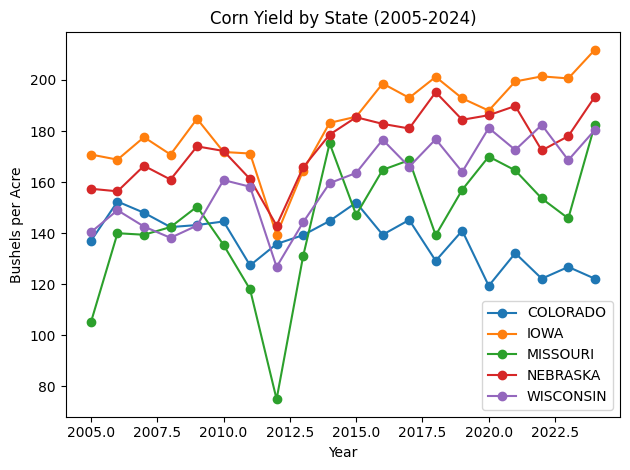

Plot saved.


In [2]:
for state, group in yield_df.groupby('state'):
    plt.plot(group['year'], group['yield_bu_acre'], marker='o', label=state)

plt.title('Corn Yield by State (2005-2024)')
plt.xlabel('Year')
plt.ylabel('Bushels per Acre')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/quickstats_yield_plot.png')
plt.show()
print('Plot saved.')